# 🐼 Pandas Part 5: Merging, Joining & Concatenating Masterclass
**Combining Multiple DataFrames like a Relational Database**

Welcome to Part 5! In the real world, data never comes in a single table. It comes in multiple CSVs, databases, and APIs. This notebook teaches you how to stitch them together using `pd.concat` (stacking) and `pd.merge` (relational joins).

Every core concept follows our **16-Step Mastery Framework**:
`Theory → Mental Model → Diagram → Syntax → Example → Output → Explanation → Mistakes → Interview → Practice (Levels 1-5) → SQL → DS Use Case`

We will culminate in **Two Massive Real-World Projects**:
1. 🎓 **Ed-Tech Analytics** (10 complex business questions)
2. 🏏 **IPL Analytics** (Stadium sixes ratio & Orange Cap holders)


In [14]:
# ==========================================
# 🛠️ SETUP & INDUSTRY MOCK DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ed-Tech Data (Students, Courses, Enrollments)
students = pd.DataFrame({
    'sid': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva']
})

courses = pd.DataFrame({
    'cid': [101, 102, 103, 104, 105],
    'course_name': ['Python', 'SQL', 'Machine Learning', 'Excel', 'Java'],
    'price': [500, 400, 800, 200, 300],
    'partner': ['CampusX', 'CampusX', 'Scaler', 'Udemy', 'Coursera']
})

enrollments_jan = pd.DataFrame({'sid': [1, 2, 1, 3], 'cid': [101, 102, 103, 101]})
enrollments_feb = pd.DataFrame({'sid': [2, 4, 1, 3], 'cid': [101, 102, 104, 102]})

# 2. IPL Data (Matches & Player Stats)
ipl_matches = pd.DataFrame({
    'match_id': [1, 2, 3, 4, 5, 6],
    'stadium': ['Wankhede', 'Eden Gardens', 'Wankhede', 'Chinnaswamy', 'Eden Gardens', 'Chinnaswamy'],
    'total_sixes': [12, 8, 15, 10, 6, 14]
})

ipl_players = pd.DataFrame({
    'season': [2022, 2022, 2022, 2023, 2023, 2023],
    'player': ['Kohli', 'Rohit', 'Dhoni', 'Kohli', 'Rohit', 'Gill'],
    'total_runs': [500, 450, 300, 600, 550, 750]
})

print("✅ Ed-Tech and IPL Mock Data Loaded Successfully!")


✅ Ed-Tech and IPL Mock Data Loaded Successfully!


# 📘 Master Module 1: Stacking Data (`pd.concat`)

## 🧠 1. Theory
`pd.concat()` is used to stack DataFrames either **vertically** (row-wise, `axis=0`) or **horizontally** (column-wise, `axis=1`). It simply glues data together without looking for matching relational keys.

## 💡 2. Mental Model
- **Vertical (`axis=0`)**: Stacking two decks of cards on top of each other.
- **Horizontal (`axis=1`)**: Gluing two pages of a book side-by-side.

## 📊 3. Visual Diagram
```text
Vertical (axis=0)                 Horizontal (axis=1)
┌─────┐  ┌─────┐                  ┌─────┐  ┌─────┐
│ A B │  │ E F │                  │ A B │  │ E F │
├─────┤  ├─────┤                  ├─────┤  ├─────┤
│ 1 2 │  │ 5 6 │   =>             │ 1 2 │  │ 5 6 │
│ 3 4 │  │ 7 8 │                  │ 3 4 │  │ 7 8 │
└─────┘  └─────┘                  └─────┘  └─────┘
    ↓        ↓                        ↓        ↓
┌─────┐                             ┌───────────┐
│ A B │                             │ A B E F   │
│ 1 2 │                             │ 1 2 5 6   │
│ 3 4 │                             │ 3 4 7 8   │
│ E F │                             └───────────┘
│ 5 6 │
└─────┘
```
```text
Vertical (axis=0)            Horizontal (axis=1)
   ┌──────────┐                 ┌──────────┬──────────┐
   │  Jan Reg │                 │ Student  │  Price   │
   ├──────────┤                 └──────────┴──────────┘
   │  Feb Reg │                            +
   └──────────┘                 ┌──────────┬──────────┐
                                │ Student  │  Status  │
                                └──────────┴──────────┘
```
## 🛠️ 4. Syntax
```python
pd.concat([df1, df2], axis=0, keys=['Jan', 'Feb']) # Vertical with MultiIndex
pd.concat([df1, df2], axis=1)                      # Horizontal
```

## 💻 5. Example & 6. Output
```python
# Concatenate Jan and Feb enrollments vertically, adding a 'month' key
enrollments = pd.concat([enrollments_jan, enrollments_feb], keys=['Jan', 'Feb'])
enrollments = enrollments.reset_index(level=0).rename(columns={'level_0': 'month'})
```
**Output:** A single DataFrame with a new `month` column indicating the source.

## 🔍 7. Step-by-Step Explanation
1. `pd.concat` stacks `enrollments_feb` below `enrollments_jan`.
2. `keys=['Jan', 'Feb']` creates a MultiIndex to track which DataFrame the row came from.
3. `reset_index(level=0)` flattens the MultiIndex into a standard column named `month`.

## ⚠️ 8. Common Mistakes
**The `df.append()` Trap:**
```python
df1.append(df2) # ❌ Deprecated and removed in Pandas 2.0!
```
**Correct:** Always use `pd.concat([df1, df2])`. It is faster and universally supported.

## 🎤 9. Interview Questions & Output Prediction
**Q: What happens if you `pd.concat` two DataFrames vertically, but they have different columns?**
**A:** Pandas will perform an **Outer Join** on the columns by default. Missing columns in either DataFrame will be filled with `NaN`.

**Q:** *How do you keep track of the original sources of your rows after calling `pd.concat` vertically?*
**Answer:** Pass a list of labels to the `keys` parameter inside `pd.concat()`. This generates a hierarchical **MultiIndex**, embedding a tracking label next to every row indicating its source dataframe.

**⚠️ Deprecation Warning:** Historically, `df.append()` was used to add rows. This was **deprecated and removed** in modern Pandas. Why? Because `append` forced expensive memory copies every single time it was called. `pd.concat()` takes a list of dataframes and allocates memory once, making it vastly faster.


**🔮 Output Prediction:**
```python
df1 = pd.DataFrame({'A': [1, 2]})
df2 = pd.DataFrame({'B': [3, 4]})
print(pd.concat([df1, df2], axis=0))
```
**Answer:**
```text
     A    B
0  1.0  NaN
1  2.0  NaN
0  NaN  3.0
1  NaN  4.0
```

## 🎯 10-14. Practice Tasks
- **Level 1 (Syntax):** Concatenate `enrollments_jan` and `enrollments_feb` vertically without keys.
- **Level 2 (Understanding):** Concatenate them horizontally (`axis=1`). Observe the duplicate `sid` and `cid` columns.
- **Level 3 (Combination):** Concatenate vertically, use `keys`, and reset the index to create a `month` column.
- **Level 4 (Real Dataset):** Create two DataFrames with slightly different columns and concat them. Handle the resulting `NaN`s using `fillna(0)`.
- **Level 5 (Challenge):** Concatenate `students` and `courses` horizontally. What happens to the rows since they have different lengths? (Hint: `NaN` padding).

1. Concatenate `reg_m1` and `reg_m2` vertically into a single DataFrame called `total_reg`.
2. Concatenate them vertically again, but this time use the `keys=['Jan', 'Feb']` parameter.
3. Horizontally concatenate the first 3 rows of `students` with the first 3 rows of `courses` using `axis=1`.

## 🗄️ 15. SQL Equivalent
- Vertical Concat: `SELECT * FROM df1 UNION ALL SELECT * FROM df2;`
- Horizontal Concat: `SELECT * FROM df1 FULL OUTER JOIN df2 ON df1.index = df2.index;`

## 🤖 16. Data Science Use Case
**Time-Series Stacking:** You receive daily CSV files of user logs. You use `pd.concat` inside a list comprehension to stack 365 daily files into one massive yearly DataFrame for ML training.


In [15]:
# ==========================================
# 💻 MODULE 1: PRACTICE & SOLUTIONS
# ==========================================
# Level 3 Solution (The standard way to combine time-split data)
enrollments = pd.concat([enrollments_jan, enrollments_feb], keys=['Jan', 'Feb'])
enrollments = enrollments.reset_index(level=0).rename(columns={'level_0': 'month'})
print("Combined Enrollments:\n", enrollments)


Combined Enrollments:
   month  sid  cid
0   Jan    1  101
1   Jan    2  102
2   Jan    1  103
3   Jan    3  101
0   Feb    2  101
1   Feb    4  102
2   Feb    1  104
3   Feb    3  102


# 📘 Master Module 2: Relational Merging (`pd.merge`)

## 🧠 1. Theory
`pd.merge()` combines DataFrames based on **common columns (keys)**, exactly like SQL JOINs. It supports `inner`, `left`, `right`, and `outer` joins.

### The 4 Major Join Types (`how` parameter):

1. **`inner` (Default):** Keeps only the rows where the key exists in **both** dataframes.
2. **`left`:** Retains *everything* from the left dataframe, matching where possible from the right. Unmatched rows are filled with `NaN`.
3. **`right`:** Retains *everything* from the right dataframe, matching where possible from the left.
4. **`outer`:** Keeps all records from both dataframes (a full union). Missing matches get `NaN`.

## 💡 2. Mental Model
Think of a **Venn Diagram**. 
- **Inner**: Only the intersection (matches in both).
- **Left**: Everything in the left circle, plus matches from the right.
- **Right**: Everything in the right circle, plus matches from the left.
- **Outer**: Everything in both circles (union).

**💡 Fun Fact:** `pd.merge(df1, df2)` and `df1.merge(df2)` do the exact same thing. The latter is just an object-oriented shortcut!

## 📊 3. Visual Diagram
```text
Left (Students)      Right (Enrollments)
sid | name           sid | cid
 1  | Alice    ⇄      1  | 101
 2  | Bob             2  | 102
 3  | Charlie         9  | 103  <-- No matching student!

INNER JOIN (Keep only matches):
sid | name    | cid
 1  | Alice   | 101
 2  | Bob     | 102

LEFT JOIN (Keep all students):
sid | name    | cid
 1  | Alice   | 101
 2  | Bob     | 102
 3  | Charlie | NaN  <-- Kept, but no enrollment data
```

```text
   Inner Join               Left Join               Outer Join
 (Intersection)           (Left Focus)             (Full Union)
   ┌───┬───┐                ┌───┬───┐               ┌───┬───┐
   │   │███│   │            │███│███│   │           │███│███│███│
   │   │███│   │            │███│███│   │           │███│███│███│
   └───┴───┘                └───┴───┘               └───┴───┘

```

## 🛠️ 4. Syntax
```python
pd.merge(left_df, right_df, on='key_column', how='inner|left|right|outer')
# Alternate syntax: left_df.merge(right_df, ...)
```

## ⚠️ 8. Common Mistakes
**The Cartesian Product Trap:**
If the `on` key is not unique in *both* DataFrames (e.g., merging on `city` where both have 5 rows for 'Mumbai'), Pandas will create a **Cartesian Product** (5 x 5 = 25 rows), exploding your memory! Always check `df['key'].is_unique` before merging.

## 🎤 9. Interview Questions & Output Prediction
**Q: What is the difference between `pd.merge()` and `pd.concat()`?**
**A:** `concat` blindly stacks data based on index/position. `merge` intelligently aligns data based on matching values in specific columns (relational keys).

**Q: How do you perform an "Anti-Join" (find records in Left that are NOT in Right)?**
**A:** Perform a `left` merge, then filter for rows where the right-side key is `NaN`. Alternatively, use the `indicator=True` parameter and filter for `_merge == 'left_only'`.

## 🎯 10-14. Practice Tasks
- **Level 1:** Merge `students` and `enrollments` using an `inner` join on `sid`.
- **Level 2:** Perform a `left` join to find all students, even those who haven't enrolled.
- **Level 3:** Perform a `right` join on `courses` and `enrollments` to find courses with no enrollments.
- **Level 4:** Use `indicator=True` in a left merge to explicitly tag rows as 'both' or 'left_only'.
- **Level 5 (Challenge):** Merge `students`, `enrollments`, and `courses` in a single chained pipeline to get a full registration table.

1. Perform an `inner` join between `students` and `reg_m1` on the `student_id` column.
2. Perform an `outer` join between `students` and `reg_m1`. Notice how some students show `NaN` for course registrations?
3. Merge `students` and `reg_m1` using a `left` join.

In [16]:
# ==========================================
# 💻 MODULE 2: PRACTICE & SOLUTIONS
# ==========================================
# Level 5 Solution: Chained Merging
registration = students.merge(enrollments, on='sid', how='inner') \
                       .merge(courses, on='cid', how='inner')
print("Full Registration Table:\n", registration)


Full Registration Table:
    sid     name month  cid       course_name  price  partner
0    1    Alice   Jan  101            Python    500  CampusX
1    1    Alice   Jan  103  Machine Learning    800   Scaler
2    1    Alice   Feb  104             Excel    200    Udemy
3    2      Bob   Jan  102               SQL    400  CampusX
4    2      Bob   Feb  101            Python    500  CampusX
5    3  Charlie   Jan  101            Python    500  CampusX
6    3  Charlie   Feb  102               SQL    400  CampusX
7    4    David   Feb  102               SQL    400  CampusX


In [ ]:
# --- EXAMPLE CODE ---
# Left Join Example (We keep all students, even if they didn't register)
left_example = students.merge(reg_m1, on='student_id', how='left')
print("Left Join (All students tracked):\n", left_example.head())

# --- PRACTICE AREA ---
# Task 1: Inner join between students and reg_m1


# Task 2: Outer join between students and reg_m1


# Task 3: Left join between students and reg_m1

# 🏆 Master Project 1: Ed-Tech Business Analytics (10 Questions)

## 🎓 Case Study: Course Enrollment Analytics
You are the Lead Data Scientist at an Ed-Tech company. The CEO has asked you 10 critical business questions based on the `students`, `courses`, and `enrollments` datasets.

**The 10 Questions:**
1. Find total revenue generated.
2. Find month-by-month revenue.
3. Print the complete registration table.
4. Plot a bar chart for revenue per course.
5. Find students who enrolled in **both** months.
6. Find courses that got **no** enrollments.
7. Find students who did **not** enroll in any courses.
8. Print Student Name & Partner Name for all enrollments.
9. Find top 3 students with the most enrollments.
10. Find top 3 students who spent the most money.


In [ ]:
# --- EXAMPLE CODE ---
# Pre-requisite: Combining registrations and tracking the month
total_reg = pd.concat([reg_m1, reg_m2], keys=['Jan', 'Feb']).reset_index(level=0).rename(columns={'level_0': 'Month'})
print("Unified Registrations:\n", total_reg.head(3))

# --- PRACTICE AREA ---
# Task 1: Merge total_reg with courses on 'course_id' (inner join) and save to 'revenue_df'


# Task 2: Print the sum of the 'price' column from revenue_df (Total Revenue)


# Task 3: Use groupby('Month') on revenue_df to find the sum of 'price' per month

1. Total Revenue: $3700.0

2. Month-by-Month Revenue:
 month
Feb    1500.0
Jan    2200.0
Name: price, dtype: float64

3. Registration Table:
    sid     name month    cid       course_name  price  partner
0    1    Alice   Jan  101.0            Python  500.0  CampusX
1    1    Alice   Jan  103.0  Machine Learning  800.0   Scaler
2    1    Alice   Feb  104.0             Excel  200.0    Udemy
3    2      Bob   Jan  102.0               SQL  400.0  CampusX
4    2      Bob   Feb  101.0            Python  500.0  CampusX
5    3  Charlie   Jan  101.0            Python  500.0  CampusX
6    3  Charlie   Feb  102.0               SQL  400.0  CampusX
7    4    David   Feb  102.0               SQL  400.0  CampusX


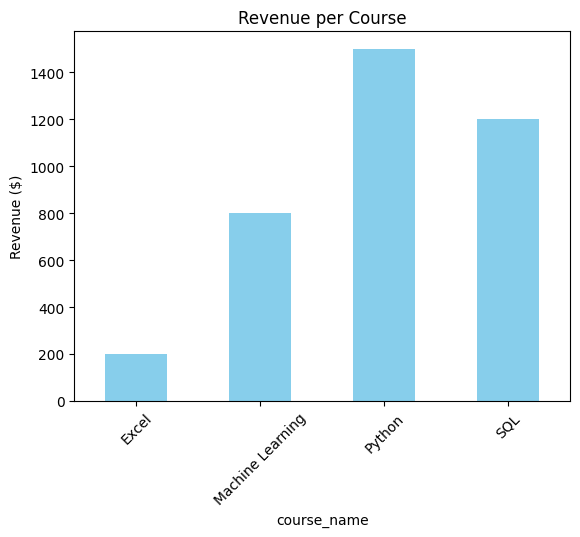


5. Students enrolled in both months:
    sid     name
0    1    Alice
1    2      Bob
2    3  Charlie


In [17]:
# ==========================================
# 🎓 ED-TECH PROJECT: SOLUTIONS 1 to 5
# ==========================================

# Ensure enrollments has the 'month' column
enrollments = pd.concat([enrollments_jan, enrollments_feb], keys=['Jan', 'Feb'])
enrollments = enrollments.reset_index(level=0).rename(columns={'level_0': 'month'})

# Merge everything for easier analysis
reg = students.merge(enrollments, on='sid', how='left').merge(courses, on='cid', how='left')

# 1. Total Revenue Generated (Sum of price for all valid enrollments)
total_rev = reg['price'].sum()
print(f"1. Total Revenue: ${total_rev}")

# 2. Month-by-Month Revenue
month_rev = reg.groupby('month')['price'].sum()
print("\n2. Month-by-Month Revenue:\n", month_rev)

# 3. Print Registration Table (Already done as 'reg', dropping NaNs for actual registrations)
print("\n3. Registration Table:\n", reg.dropna(subset=['cid']))

# 4. Bar Chart for Revenue per Course
course_rev = reg.groupby('course_name')['price'].sum()
course_rev.plot(kind='bar', color='skyblue', title='Revenue per Course')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.show()

# 5. Students who enrolled in BOTH months
# Find sids present in Jan AND Feb
jan_sids = set(enrollments_jan['sid'])
feb_sids = set(enrollments_feb['sid'])
both_sids = jan_sids.intersection(feb_sids)
both_students = students[students['sid'].isin(both_sids)]
print("\n5. Students enrolled in both months:\n", both_students)


In [18]:
# ==========================================
# 🎓 ED-TECH PROJECT: SOLUTIONS 6 to 10
# ==========================================

# 6. Courses with NO enrollments (Anti-Join / Right Join)
# Merge courses (left) with enrollments (right) -> Wait, courses is left here.
course_enroll = courses.merge(enrollments, on='cid', how='left')
no_enroll_courses = course_enroll[course_enroll['sid'].isnull()]['course_name']
print("6. Courses with no enrollments:\n", no_enroll_courses.tolist())

# 7. Students who did NOT enroll (Anti-Join / Left Join)
student_enroll = students.merge(enrollments, on='sid', how='left')
no_enroll_students = student_enroll[student_enroll['cid'].isnull()]['name']
print("\n7. Students with no enrollments:\n", no_enroll_students.tolist())

# 8. Student Name -- Partner Name for all enrolled students
student_partner = reg[['name', 'partner']].dropna()
print("\n8. Student - Partner Mapping:\n", student_partner)

# 9. Top 3 students with most enrollments
top_enrollments = reg.dropna().groupby('name')['cid'].count().sort_values(ascending=False).head(3)
print("\n9. Top 3 Students by Enrollments:\n", top_enrollments)

# 10. Top 3 students who spent the most money
top_spenders = reg.dropna().groupby('name')['price'].sum().sort_values(ascending=False).head(3)
print("\n10. Top 3 Students by Money Spent:\n", top_spenders)


6. Courses with no enrollments:
 ['Java']

7. Students with no enrollments:
 ['Eva']

8. Student - Partner Mapping:
       name  partner
0    Alice  CampusX
1    Alice   Scaler
2    Alice    Udemy
3      Bob  CampusX
4      Bob  CampusX
5  Charlie  CampusX
6  Charlie  CampusX
7    David  CampusX

9. Top 3 Students by Enrollments:
 name
Alice      3
Bob        2
Charlie    2
Name: cid, dtype: int64

10. Top 3 Students by Money Spent:
 name
Alice      1500.0
Bob         900.0
Charlie     900.0
Name: price, dtype: float64


# 🏆 Master Project 2: IPL Analytics (Stadiums & Orange Cap)

## 🏏 Case Study: IPL Deep Dive
The BCCI has hired you to analyze stadium boundaries and seasonal top scorers.

**Questions:**
1. Find the **top 3 stadiums** with the highest **sixes per match ratio**.
2. Find the **Orange Cap holder** (highest run-scorer) for **all seasons**.


In [19]:
# ==========================================
# 🏏 IPL PROJECT: SOLUTIONS
# ==========================================

# 1. Top 3 stadiums with highest sixes/match ratio
# We need total sixes per stadium, and total matches per stadium
stadium_stats = ipl_matches.groupby('stadium').agg(
    total_sixes=('total_sixes', 'sum'),
    matches_played=('match_id', 'count')
).reset_index()

# Calculate ratio
stadium_stats['sixes_per_match'] = stadium_stats['total_sixes'] / stadium_stats['matches_played']

# Sort and get top 3
top_stadiums = stadium_stats.sort_values('sixes_per_match', ascending=False).head(3)
print("--- 1. Top 3 Stadiums by Sixes/Match Ratio ---")
print(top_stadiums[['stadium', 'sixes_per_match']])


# 2. Orange Cap Holder of ALL seasons (Top scorer per season)
# Group by season and player, sum runs (already summed in mock data, but good practice)
season_runs = ipl_players.groupby(['season', 'player'])['total_runs'].sum().reset_index()

# Find the max runs per season, then merge back to get the player name
# Method 1: Using sort_values and drop_duplicates
orange_cap = season_runs.sort_values(['season', 'total_runs'], ascending=[True, False]) \
                        .drop_duplicates(subset=['season'], keep='first')

print("\n--- 2. Orange Cap Holders (All Seasons) ---")
print(orange_cap[['season', 'player', 'total_runs']])

# Method 2 (Alternative using idxmax):
# idx = season_runs.groupby('season')['total_runs'].idxmax()
# orange_cap_alt = season_runs.loc[idx]


--- 1. Top 3 Stadiums by Sixes/Match Ratio ---
        stadium  sixes_per_match
2      Wankhede             13.5
0   Chinnaswamy             12.0
1  Eden Gardens              7.0

--- 2. Orange Cap Holders (All Seasons) ---
   season player  total_runs
1    2022  Kohli         500
3    2023   Gill         750


In [22]:

# ==========================================
# 🛠️ RELATIONAL MOCK DATA SETUP
# ==========================================

# 1. Ed-Tech Dataset Components
students = pd.DataFrame({
    'student_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'name': ['Nitish', 'Ankit', 'Rupesh', 'Rishabh', 'Amit', 'Ankita', 'Rahul', 'Priya', 'Aman', 'Sneha'],
    'partner_id': [2, 1, 4, 3, 6, 5, np.nan, 9, 8, np.nan]
})

courses = pd.DataFrame({
    'course_id': [101, 102, 103, 104, 105, 106],
    'course_name': ['Python Mastery', 'Machine Learning', 'Deep Learning', 'SQL Analytics', 'PowerBI BI', 'Data Structures'],
    'price': [4999, 9999, 12999, 3499, 2999, 5999]
})

reg_m1 = pd.DataFrame({'student_id': [1, 3, 5, 1, 7, 3, 8], 'course_id': [101, 102, 101, 103, 104, 105, 102]})
reg_m2 = pd.DataFrame({'student_id': [1, 2, 5, 9, 2, 3, 1], 'course_id': [104, 101, 103, 102, 105, 101, 102]})

# 2. IPL Datasets Components
ipl_matches = pd.DataFrame({
    'match_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'season': ['2021', '2021', '2021', '2022', '2022', '2022', '2023', '2023'],
    'venue': ['Wankhede Stadium', 'M. Chinnaswamy Stadium', 'Wankhede Stadium', 'MA Chidambaram Stadium', 'M. Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'Narendra Modi Stadium', 'Wankhede Stadium']
})

ipl_deliveries = pd.DataFrame({
    'match_id': [1, 1, 1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8],
    'batsman': ['V Kohli', 'V Kohli', 'AB de Villiers', 'MS Dhoni', 'S Raina', 'V Kohli', 'V Kohli', 'AB de Villiers', 'JC Buttler', 'Sanju Samson', 'MS Dhoni', 'Ruturaj Gaikwad', 'JC Buttler', 'Sanju Samson', 'Shubman Gill', 'Hardik Pandya', 'Faf du Plessis', 'Glenn Maxwell'],
    'batsman_runs': [6, 1, 6, 4, 6, 6, 6, 4, 6, 6, 4, 6, 6, 1, 6, 4, 6, 6]
})

print("✅ Relational Database Models Initialized!")

✅ Relational Database Models Initialized!


## Ed-Tech Case Study: Multi-Table Analytics (Part 1)

Let's solve real-world corporate business intelligence questions using our Student/Course/Registration datasets.

First, we will unify the registrations into one master frame.

### 🎯 Practice Tasks

1. Combine `reg_m1` and `reg_m2` vertically into `total_reg`.
2. Find the **Total Revenue** generated. *(Hint: Merge `total_reg` with `courses` on `course_id`, then sum the `price` column).*
3. Find **Month-by-Month Revenue**. *(Hint: Use the `keys` parameter when concatenating to keep track of the month, reset the index, then merge with `courses` and group by the month).*


In [23]:
# --- EXAMPLE CODE ---
# Pre-requisite: Combining registrations and tracking the month
total_reg = pd.concat([reg_m1, reg_m2], keys=['Jan', 'Feb']).reset_index(level=0).rename(columns={'level_0': 'Month'})
print("Unified Registrations:\n", total_reg.head(3))

# --- PRACTICE AREA ---
# Task 1: Merge total_reg with courses on 'course_id' (inner join) and save to 'revenue_df'


# Task 2: Print the sum of the 'price' column from revenue_df (Total Revenue)


# Task 3: Use groupby('Month') on revenue_df to find the sum of 'price' per month


Unified Registrations:
   Month  student_id  course_id
0   Jan           1        101
1   Jan           3        102
2   Jan           5        101


## Ed-Tech Case Study: Multi-Table Analytics (Part 2)

Now we analyze student behaviors and course popularity.

### 🎯 Practice Tasks

1. Plot a Bar Chart showing **Revenue per Course**. *(Hint: Group `revenue_df` by `course_name`, sum the `price`, and call `.plot(kind='bar')`).*
2. Find students who enrolled in **both** months. *(Hint: Extract unique `student_id` arrays from `reg_m1` and `reg_m2` and use `np.intersect1d(arr1, arr2)`).*
3. Find courses that got **zero enrollments**. *(Hint: Get unique courses from `total_reg`. Then filter the `courses` dataframe to find IDs that are NOT IN `~isin()` that list).*


In [24]:
# --- EXAMPLE CODE ---
# Creating a Master Registration Table with all names and course info
master_reg = total_reg.merge(students, on='student_id').merge(courses, on='course_id')
print("Master Registration Table:\n", master_reg[['name', 'course_name', 'price']].head(3))

# --- PRACTICE AREA ---
# Task 1: Group master_reg by 'course_name', sum the 'price', and plot a bar chart. (Use plt.show() after)


# Task 2: Find students enrolled in BOTH January and February using np.intersect1d


# Task 3: Find courses that got ZERO enrollments using ~isin()


Master Registration Table:
      name       course_name  price
0  Nitish    Python Mastery   4999
1  Rupesh  Machine Learning   9999
2    Amit    Python Mastery   4999



## Ed-Tech Case Study: Complex Merges & Self Joins

A **Self-Join** is when a table is merged with itself. This is highly useful when a dataset contains hierarchical or relational mappings within its own columns (like finding a manager's name for an employee, or a study partner's name for a student).

### 🎯 Practice Tasks

1. Find students who did **not enroll** in any courses at all. *(Hint: Use `~isin()` checking `students` against `total_reg`)*.
2. Find the top 3 students who spent the **most amount of money**. *(Hint: Group `master_reg` by `name`, sum the `price`, sort descending, and grab `.head(3)`).*
3. **Self-Join Challenge:** Print the student's name next to their partner's name. *(Hint: Merge `students` with `students`, mapping `left_on='partner_id'` to `right_on='student_id'`).*


In [25]:
# --- EXAMPLE CODE ---
# Finding the top 3 students who did the most total enrollments
top_enrollers = master_reg['name'].value_counts().head(3)
print("Top 3 Enrollers:\n", top_enrollers)

# --- PRACTICE AREA ---
# Task 1: Print students who did not enroll in any courses


# Task 2: Find the top 3 students who spent the most money


# Task 3: Self-join the 'students' dataframe to map student names to partner names.
# (Pass suffixes=('_student', '_partner') to keep column names clean)


Top 3 Enrollers:
 name
Nitish    4
Rupesh    3
Amit      2
Name: count, dtype: int64


## IPL Analytics: Relational Mathematics

Data combinations are essential for calculating complex ratios across different dimensions (e.g., matching delivery outcomes to stadium metadata).

**Analytical Goal 1:** Find the top 3 stadiums with the highest Sixes-per-Match ratio.


$$\text{Ratio} = \frac{\text{Total Sixes Hit at Stadium}}{\text{Total Matches Played at Stadium}}$$

**Analytical Goal 2:** Find the Orange Cap Holder (highest run-scorer) of every season.

### 🎯 Practice Tasks

1. Find the total matches played at each venue by running `value_counts()` on `ipl_matches['venue']`.
2. Filter `ipl_deliveries` to keep only rows where `batsman_runs == 6`. Merge this with `ipl_matches` on `match_id`, then count the sixes per venue.
3. Divide the sixes by the matches to find the ratio, sort descending, and print the top 3!


In [26]:
# --- EXAMPLE CODE ---
# Goal 2 Solution: Orange Cap Holder per Season
# Merge deliveries with matches to get the season for every ball bowled
seasonal_runs = ipl_deliveries.merge(ipl_matches, on='match_id', how='inner')

# Group by season and batsman to get total runs
player_season_totals = seasonal_runs.groupby(['season', 'batsman'])['batsman_runs'].sum().reset_index()

# Find the row index of the max runs for each season
orange_cap_indices = player_season_totals.groupby('season')['batsman_runs'].idxmax()
orange_cap_holders = player_season_totals.loc[orange_cap_indices]
print("👑 Orange Cap Holders per Season:\n", orange_cap_holders)

# --- PRACTICE AREA ---
# Task 1: Find total matches per venue


# Task 2: Filter deliveries for 6s, merge with matches, count sixes per venue


# Task 3: Calculate the ratio, sort descending, print top 3 stadiums


👑 Orange Cap Holders per Season:
   season         batsman  batsman_runs
3   2021         V Kohli            19
4   2022      JC Buttler            12
8   2023  Faf du Plessis             6


# 🎤 Interview Questions & Cheat Sheet

**Q1: What is the difference between `merge()` and `join()`?**
**A:** `merge()` is versatile and joins on **columns** (or indices). `join()` is a convenience method that strictly joins on **indices** (and defaults to left join). Under the hood, `join()` actually calls `merge()`.

**Q2: How do you handle merging when the key columns have different names?**
**A:** Use `left_on` and `right_on` parameters.
```python
pd.merge(df1, df2, left_on='user_id', right_on='uid')
```

**Q3: What happens if you merge on a key that has duplicate values in both DataFrames?**
**A:** Pandas performs a **Cartesian Product** for those keys. If 'A' appears 3 times in Left and 2 times in Right, the result will have 3 x 2 = 6 rows for 'A'. This can cause massive memory spikes.

**Q4: How do you keep track of which DataFrame a row originated from after an outer merge?**
**A:** Use the `indicator=True` parameter. It adds a `_merge` column with values `'left_only'`, `'right_only'`, or `'both'`.

**Q5: Why is `pd.concat` preferred over `df.append`?**
**A:** `df.append()` was deprecated in Pandas 1.4 and removed in 2.0. It was inefficient because it created a new DataFrame in memory for every single append operation. `pd.concat()` takes a list of DataFrames and combines them in a single, highly optimized C-level pass.

---

## 🚀 Pandas Merging Ultimate Cheat Sheet

| Operation | Syntax | Purpose |
|-----------|--------|---------|
| **Vertical Stack** | `pd.concat([df1, df2], axis=0)` | Stack rows on top of each other |
| **Horizontal Stack** | `pd.concat([df1, df2], axis=1)` | Glue columns side-by-side |
| **MultiIndex Stack** | `pd.concat([df1, df2], keys=['A', 'B'])` | Track source DataFrame |
| **Inner Join** | `pd.merge(df1, df2, on='id', how='inner')` | Keep only matching keys |
| **Left Join** | `pd.merge(df1, df2, on='id', how='left')` | Keep all left keys |
| **Right Join** | `pd.merge(df1, df2, on='id', how='right')` | Keep all right keys |
| **Outer Join** | `pd.merge(df1, df2, on='id', how='outer')` | Keep all keys from both |
| **Anti-Join (Left)** | `merge(how='left', indicator=True).query('_merge=="left_only"')` | Find rows in Left NOT in Right |
| **Different Keys** | `merge(left_on='uid', right_on='user_id')` | Merge on mismatched column names |
```

# 🎉 Congratulations!
You have mastered **Pandas Part 5: Merging, Joining, and Concatenating**. 

You now know how to:
✅ Stack DataFrames vertically and horizontally using `pd.concat`.
✅ Perform relational SQL-style joins (Inner, Left, Right, Outer) using `pd.merge`.
✅ Execute Anti-Joins to find missing relationships.
✅ Solve complex, multi-table business analytics problems (Ed-Tech & IPL).

### 🚀 Next Steps
You have now completed the core Pandas curriculum! You are ready for **Pandas Part 6: Time Series Analysis & Window Functions** – handling dates, resampling, and rolling averages!